In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

In [ ]:
CSV_PATH   = "Training_set.csv" 
IMAGE_DIR  = "Dataset/train"              
IMG_SIZE   = (150, 150)

In [10]:
df = pd.read_csv(CSV_PATH)
print(df.head())


      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART


In [9]:
print("Total images:", len(df))
print("Classes:", df['label'].nunique())

Total images: 6499
Classes: 75


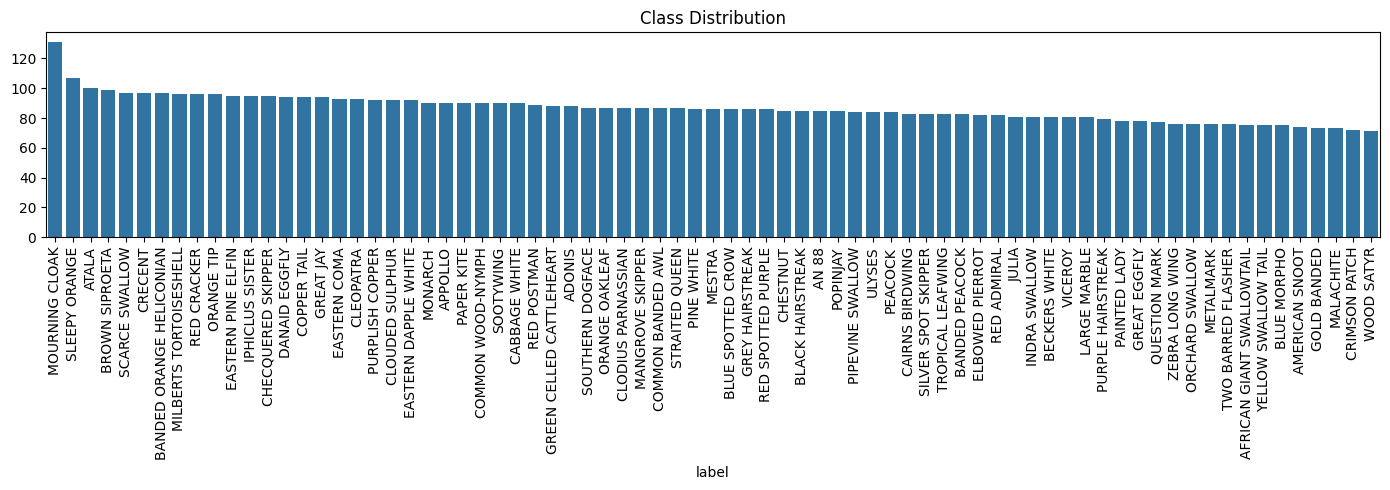

In [11]:
plt.figure(figsize=(14, 5))
sns.barplot(x=df['label'].value_counts().index,
            y=df['label'].value_counts().values)
plt.title("Class Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f"Classes ({NUM_CLASSES}):", le.classes_)

Classes (75): ['ADONIS' 'AFRICAN GIANT SWALLOWTAIL' 'AMERICAN SNOOT' 'AN 88' 'APPOLLO'
 'ATALA' 'BANDED ORANGE HELICONIAN' 'BANDED PEACOCK' 'BECKERS WHITE'
 'BLACK HAIRSTREAK' 'BLUE MORPHO' 'BLUE SPOTTED CROW' 'BROWN SIPROETA'
 'CABBAGE WHITE' 'CAIRNS BIRDWING' 'CHECQUERED SKIPPER' 'CHESTNUT'
 'CLEOPATRA' 'CLODIUS PARNASSIAN' 'CLOUDED SULPHUR' 'COMMON BANDED AWL'
 'COMMON WOOD-NYMPH' 'COPPER TAIL' 'CRECENT' 'CRIMSON PATCH'
 'DANAID EGGFLY' 'EASTERN COMA' 'EASTERN DAPPLE WHITE'
 'EASTERN PINE ELFIN' 'ELBOWED PIERROT' 'GOLD BANDED' 'GREAT EGGFLY'
 'GREAT JAY' 'GREEN CELLED CATTLEHEART' 'GREY HAIRSTREAK' 'INDRA SWALLOW'
 'IPHICLUS SISTER' 'JULIA' 'LARGE MARBLE' 'MALACHITE' 'MANGROVE SKIPPER'
 'MESTRA' 'METALMARK' 'MILBERTS TORTOISESHELL' 'MONARCH' 'MOURNING CLOAK'
 'ORANGE OAKLEAF' 'ORANGE TIP' 'ORCHARD SWALLOW' 'PAINTED LADY'
 'PAPER KITE' 'PEACOCK' 'PINE WHITE' 'PIPEVINE SWALLOW' 'POPINJAY'
 'PURPLE HAIRSTREAK' 'PURPLISH COPPER' 'QUESTION MARK' 'RED ADMIRAL'
 'RED CRACKER' 'RED POSTMAN'

In [15]:
def load_images(dataframe, image_dir, img_size):
    X, y = [], []
    missing = 0
    for _, row in dataframe.iterrows():
        path = os.path.join(image_dir, row['filename'])
        if not os.path.exists(path):
            missing += 1
            continue
        img   = load_img(path, target_size=img_size)
        arr   = img_to_array(img) / 255.0         
        X.append(arr)
        y.append(row['label_encoded'])
    if missing:
        print(f" images not found ")
    return np.array(X), np.array(y)

X, y = load_images(df, IMAGE_DIR, IMG_SIZE)
print(f"X shape: {X.shape}  |  y shape: {y.shape}")

X shape: (6499, 150, 150, 3)  |  y shape: (6499,)


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")

Train: 5199  |  Val: 1300


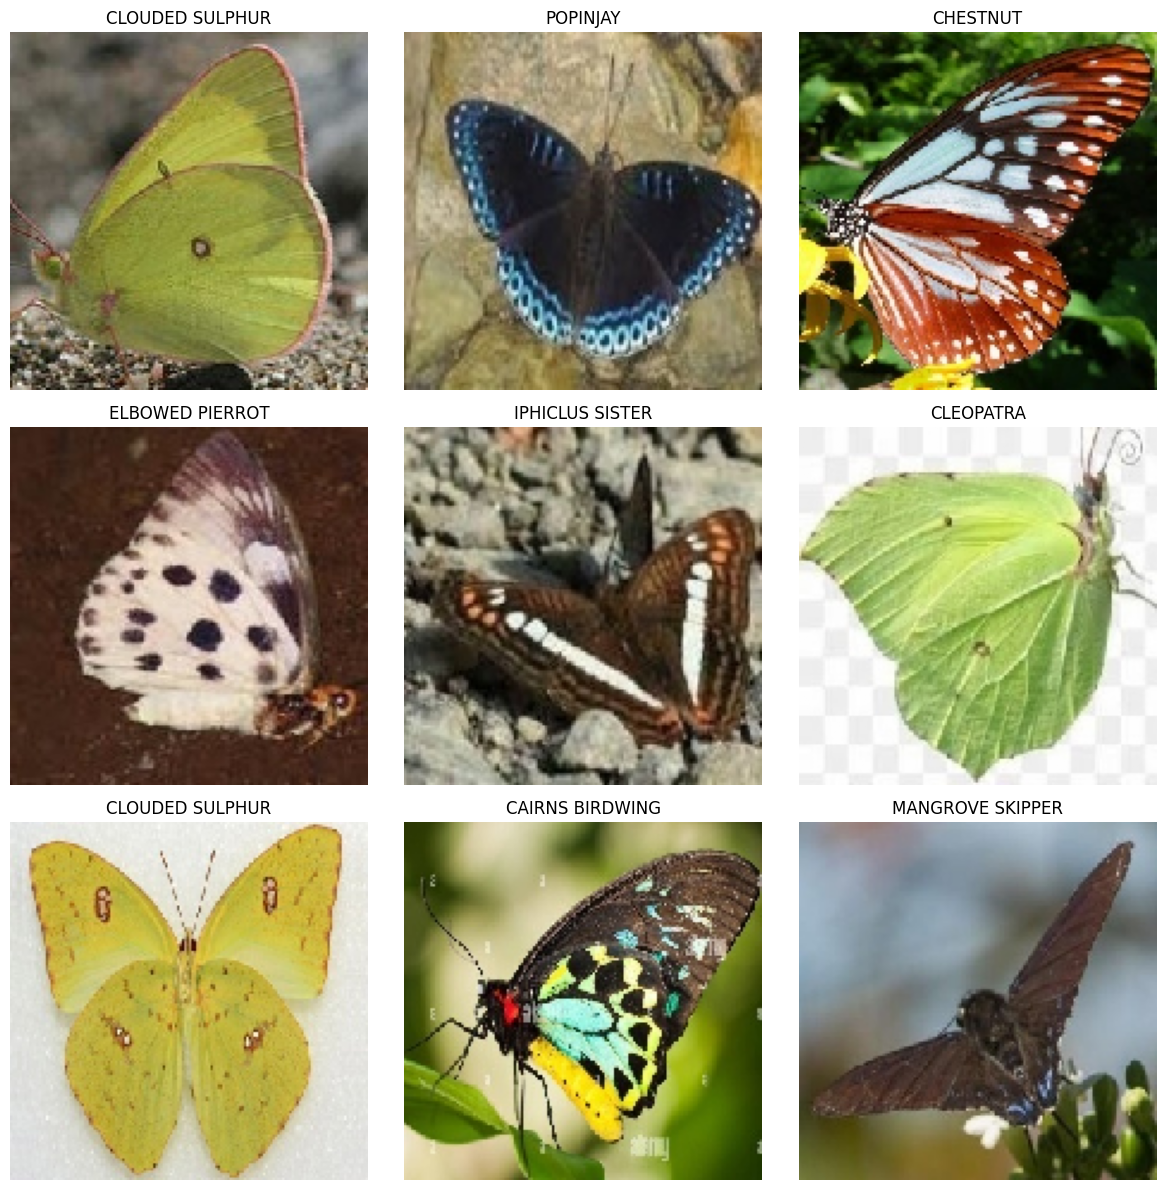

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
idx = np.random.choice(len(X_train), 9, replace=False)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[idx[i]])
    ax.set_title(le.classes_[y_train[idx[i]]])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [18]:
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(*IMG_SIZE, 3)),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Block 3 — added for better feature extraction
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),                          # reduces overfitting
    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

c:\Users\User\anaconda3\envs\mlb\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,582,731 (36.56 MB)

 Trainable params: 9,582,731 (36.56 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # works directly with integer labels
    metrics=['accuracy']
)


In [23]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 301ms/step - accuracy: 0.2821 - loss: 2.7904 - val_accuracy: 0.4569 - val_loss: 2.0865
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 330ms/step - accuracy: 0.4541 - loss: 2.0301 - val_accuracy: 0.5131 - val_loss: 1.8162
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 297ms/step - accuracy: 0.5791 - loss: 1.5129 - val_accuracy: 0.5454 - val_loss: 1.7064
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 315ms/step - accuracy: 0.6839 - loss: 1.0622 - val_accuracy: 0.5500 - val_loss: 1.7255
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 307ms/step - accuracy: 0.7547 - loss: 0.8279 - val_accuracy: 0.5792 - val_loss: 1.6296


In [25]:
loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\nValidation accuracy: {acc:.4f}  |  Loss: {loss:.4f}")


Validation accuracy: 0.5792  |  Loss: 1.6296


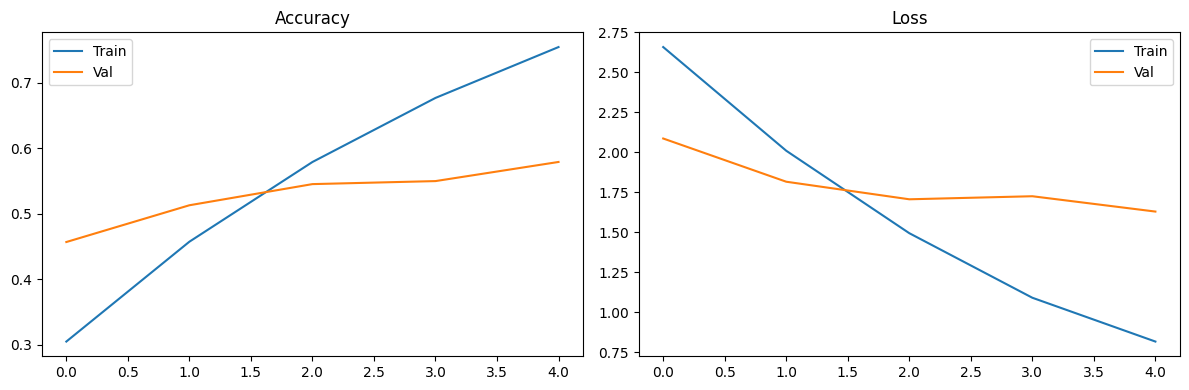

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step

Classification Report:
                           precision    recall  f1-score   support

                   ADONIS       0.65      0.83      0.73        18
AFRICAN GIANT SWALLOWTAIL       0.91      0.67      0.77        15
           AMERICAN SNOOT       0.19      0.40      0.26        15
                    AN 88       1.00      0.88      0.94        17
                  APPOLLO       0.69      0.61      0.65        18
                    ATALA       0.50      0.60      0.55        20
 BANDED ORANGE HELICONIAN       0.64      0.45      0.53        20
           BANDED PEACOCK       0.75      0.53      0.62        17
            BECKERS WHITE       0.37      0.44      0.40        16
         BLACK HAIRSTREAK       0.57      0.47      0.52        17
              BLUE MORPHO       0.50      0.47      0.48        15
        BLUE SPOTTED CROW       0.33      0.47      0.39        17
           BROWN SIPROETA       0.54      0.75      0.62        

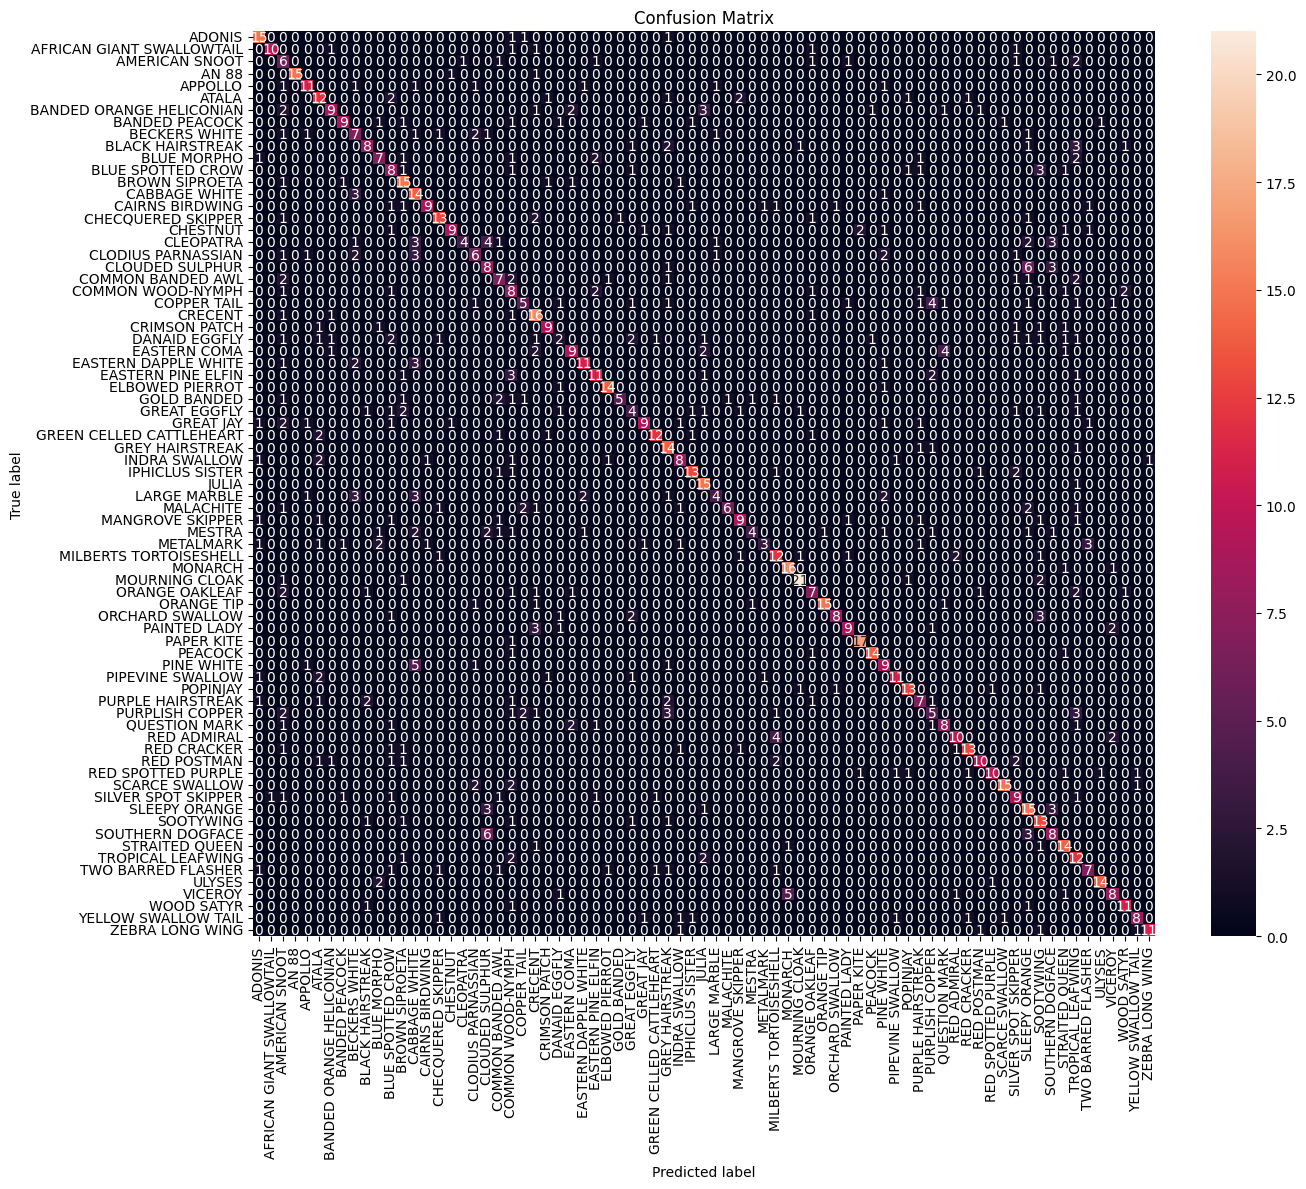

In [27]:
y_pred = np.argmax(model.predict(X_val), axis=1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


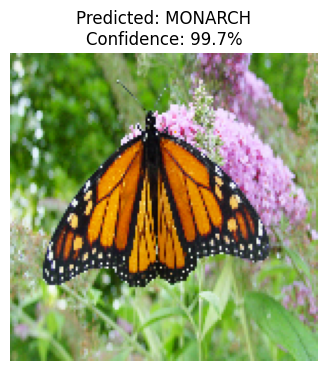

Predicted class : MONARCH
Confidence      : 99.7%

Top 5 predictions:
                    class  probability
                  MONARCH    99.714073
           STRAITED QUEEN     0.126794
                  VICEROY     0.033941
 BANDED ORANGE HELICONIAN     0.029178
AFRICAN GIANT SWALLOWTAIL     0.027394


In [24]:
TEST_IMAGE_PATH = "test_butterfly.jpg"

# Load & preprocess — must match training size
img       = load_img(TEST_IMAGE_PATH, target_size=IMG_SIZE)
img_array = img_to_array(img) / 255.0        # normalise
img_array = np.expand_dims(img_array, axis=0) # shape: (1, 150, 150, 3)
                                               # model expects a batch dimension

# Predict
predictions  = model.predict(img_array)        # shape: (1, NUM_CLASSES)
predicted_idx   = np.argmax(predictions[0])
predicted_label = le.classes_[predicted_idx]
confidence      = predictions[0][predicted_idx] * 100

# Show result
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence:.1f}%")
plt.axis('off')
plt.show()

print(f"Predicted class : {predicted_label}")
print(f"Confidence      : {confidence:.1f}%")

# Optional — see all class probabilities
prob_df = pd.DataFrame({
    'class':       le.classes_,
    'probability': predictions[0] * 100
}).sort_values('probability', ascending=False)

print("\nTop 5 predictions:")
print(prob_df.head(5).to_string(index=False))

In [28]:
model.save("butterfly_cnn.keras")
print("Model saved to butterfly_cnn.keras")

Model saved to butterfly_cnn.keras


In [29]:
np.save("label_classes.npy", le.classes_)